# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  

`Student Name`: Anjelica

`Roll Number`: U20230145
 

## 1. Setup & Installation

In [1]:
!pip install rlcmab-sampler pandas matplotlib scikit-learn seaborn xgboost -q

## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier

try:
    import xgboost as xgb
    HAS_XGBOOST = True
    print("✓ XGBoost available")
except ImportError:
    HAS_XGBOOST = False
    print("⚠ XGBoost not available (using Gradient Boosting)")

from rlcmab_sampler import sampler

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

✓ XGBoost available


## 3. Load Data

In [3]:
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print("Dataset Shapes:")
print(f"  News Articles: {news_df.shape}")
print(f"  Training Users: {train_users.shape}")
print(f"  Test Users: {test_users.shape}")

Dataset Shapes:
  News Articles: (209527, 6)
  Training Users: (2000, 33)
  Test Users: (2000, 32)


## 4. Category Mapping

In [4]:
category_mapping = {
    'ENTERTAINMENT': 'Entertainment', 'COMEDY': 'Entertainment', 'PARENTING': 'Entertainment',
    'STYLE & BEAUTY': 'Entertainment', 'FOOD & DRINK': 'Entertainment', 'TRAVEL': 'Entertainment',
    'WEDDINGS': 'Entertainment', 'HOME & LIVING': 'Entertainment', 'ARTS': 'Entertainment',
    'CULTURE & ARTS': 'Entertainment', 'MEDIA': 'Entertainment', 'TASTE': 'Entertainment',
    'EDUCATION': 'Education', 'COLLEGE': 'Education', 'PARENTS': 'Education',
    'WELLNESS': 'Education', 'HEALTHY LIVING': 'Education', 'QUEER VOICES': 'Education',
    'RELIGION': 'Education',
    'TECH': 'Tech', 'SCIENCE': 'Tech', 'BUSINESS': 'Tech', 'MONEY': 'Tech',
    'ENVIRONMENT': 'Tech', 'GREEN': 'Tech',
    'CRIME': 'Crime', 'POLITICS': 'Crime', 'U.S. NEWS': 'Crime', 'WORLD NEWS': 'Crime',
    'WORLDPOST': 'Crime', 'BLACK VOICES': 'Crime', 'LATINO VOICES': 'Crime',
    'WOMEN': 'Crime', 'IMPACT': 'Crime', 'DIVORCE': 'Crime', 'FIFTY': 'Crime',
    'GOOD NEWS': 'Crime', 'THE WORLDPOST': 'Crime', 'WEIRD NEWS': 'Crime'
}

news_df['mapped_category'] = news_df['category'].map(category_mapping).fillna('Entertainment')

## 5. Label Encoding

In [5]:
label_encoder = LabelEncoder()
train_users['label_encoded'] = label_encoder.fit_transform(train_users['label'])

if 'label' in test_users.columns:
    test_users['label_encoded'] = label_encoder.transform(test_users['label'])
    y_test = test_users['label_encoded'].values
else:
    y_test = None

print("Label Encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} -> {i}")

Label Encoding:
  user_1 -> 0
  user_2 -> 1
  user_3 -> 2


## 6. Feature Selection & Missing Values

In [6]:
# Get numeric features
train_numeric = train_users.select_dtypes(include=[np.number]).columns.tolist()
test_numeric = test_users.select_dtypes(include=[np.number]).columns.tolist()

exclude_cols = ['user_id', 'label_encoded']
train_numeric = [col for col in train_numeric if col not in exclude_cols and 'label' not in col.lower()]
test_numeric = [col for col in test_numeric if col not in exclude_cols and 'label' not in col.lower()]

common_features = sorted(list(set(train_numeric) & set(test_numeric)))

# Fill missing values
for col in common_features:
    median_val = train_users[col].median()
    train_users[col] = train_users[col].fillna(median_val)
    test_users[col] = test_users[col].fillna(median_val)

print(f"✓ Base features: {len(common_features)}")

✓ Base features: 28


## 7. ENHANCED Feature Engineering



In [7]:
def add_advanced_features(df):
    """Enhanced feature engineering for better accuracy"""
    df_copy = df.copy()
    
    # === Basic Ratios ===
    if 'age' in df.columns and 'income' in df.columns:
        df_copy['age_income_ratio'] = df['age'] / (df['income'] + 1)
        df_copy['income_per_age'] = df['income'] / (df['age'] + 1)
    
    if 'clicks' in df.columns and 'purchase_amount' in df.columns:
        df_copy['purchase_per_click'] = df['purchase_amount'] / (df['clicks'] + 1)
        df_copy['clicks_per_purchase'] = df['clicks'] / (df['purchase_amount'] + 1)
    
    if 'num_transactions' in df.columns and 'purchase_amount' in df.columns:
        df_copy['avg_transaction_value'] = df['purchase_amount'] / (df['num_transactions'] + 1)
    
    if 'time_on_site' in df.columns and 'product_views' in df.columns:
        df_copy['time_per_view'] = df['time_on_site'] / (df['product_views'] + 1)
        df_copy['views_per_hour'] = df['product_views'] / (df['time_on_site'] / 3600 + 1)
    
    if 'engagement_score' in df.columns and 'clicks' in df.columns:
        df_copy['engagement_per_click'] = df['engagement_score'] / (df['clicks'] + 1)
    
    # === Polynomial Features (squares for key metrics) ===
    if 'purchase_amount' in df.columns:
        df_copy['purchase_amount_squared'] = df['purchase_amount'] ** 2
    
    if 'engagement_score' in df.columns:
        df_copy['engagement_score_squared'] = df['engagement_score'] ** 2
        
    if 'loyalty_index' in df.columns:
        df_copy['loyalty_index_squared'] = df['loyalty_index'] ** 2
    
    # === Interaction Features ===
    if 'churn_risk_score' in df.columns and 'loyalty_index' in df.columns:
        df_copy['churn_loyalty_interaction'] = df['churn_risk_score'] * df['loyalty_index']
        df_copy['churn_loyalty_diff'] = df['loyalty_index'] - df['churn_risk_score']
    
    if 'engagement_score' in df.columns and 'loyalty_index' in df.columns:
        df_copy['engagement_loyalty_product'] = df['engagement_score'] * df['loyalty_index']
    
    # === Quantile-based Flags ===
    if 'churn_risk_score' in df.columns:
        q75 = df['churn_risk_score'].quantile(0.75)
        q25 = df['churn_risk_score'].quantile(0.25)
        df_copy['high_churn_risk'] = (df['churn_risk_score'] > q75).astype(int)
        df_copy['low_churn_risk'] = (df['churn_risk_score'] < q25).astype(int)
    
    if 'loyalty_index' in df.columns:
        q75 = df['loyalty_index'].quantile(0.75)
        q25 = df['loyalty_index'].quantile(0.25)
        df_copy['high_loyalty'] = (df['loyalty_index'] > q75).astype(int)
        df_copy['low_loyalty'] = (df['loyalty_index'] < q25).astype(int)
    
    if 'engagement_score' in df.columns:
        median = df['engagement_score'].median()
        df_copy['high_engagement'] = (df['engagement_score'] > median).astype(int)
    
    # === Value Category Flags ===
    if 'purchase_amount' in df.columns:
        q33 = df['purchase_amount'].quantile(0.33)
        q66 = df['purchase_amount'].quantile(0.66)
        df_copy['low_spender'] = (df['purchase_amount'] < q33).astype(int)
        df_copy['high_spender'] = (df['purchase_amount'] > q66).astype(int)
    
    # === Activity Level ===
    if 'clicks' in df.columns:
        median_clicks = df['clicks'].median()
        df_copy['high_activity'] = (df['clicks'] > median_clicks).astype(int)
    
    # === Combined Behavior Score ===
    if all(col in df.columns for col in ['engagement_score', 'loyalty_index', 'purchase_amount']):
        # Normalize and combine
        eng_norm = (df['engagement_score'] - df['engagement_score'].min()) / (df['engagement_score'].max() - df['engagement_score'].min() + 1e-5)
        loy_norm = (df['loyalty_index'] - df['loyalty_index'].min()) / (df['loyalty_index'].max() - df['loyalty_index'].min() + 1e-5)
        pur_norm = (df['purchase_amount'] - df['purchase_amount'].min()) / (df['purchase_amount'].max() - df['purchase_amount'].min() + 1e-5)
        df_copy['combined_behavior_score'] = eng_norm + loy_norm + pur_norm
    
    return df_copy

# Apply enhanced feature engineering
train_users_enhanced = add_advanced_features(train_users)
test_users_enhanced = add_advanced_features(test_users)

# Get all numeric features
engineered_features = [col for col in train_users_enhanced.columns 
                      if col in test_users_enhanced.columns 
                      and col not in ['user_id', 'label', 'label_encoded']
                      and train_users_enhanced[col].dtype in [np.float64, np.int64]]

print(f"✓ Total features after engineering: {len(engineered_features)}")

✓ Total features after engineering: 51


## 8. Feature Scaling & Selection

**Using 40 features** (instead of 20) to capture more patterns.

In [8]:
# Prepare feature matrices
X_train_full = train_users_enhanced[engineered_features].values
y_train_full = train_users_enhanced['label_encoded'].values
X_test_full = test_users_enhanced[engineered_features].values

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)

# Select top 40 features (more features = better accuracy)
k_best = min(40, len(engineered_features))
selector = SelectKBest(f_classif, k=k_best)
X_train_selected = selector.fit_transform(X_train_scaled, y_train_full)
X_test_selected = selector.transform(X_test_scaled)

# Get selected feature names
selected_mask = selector.get_support()
selected_features = [f for f, selected in zip(engineered_features, selected_mask) if selected]

print(f"✓ Selected top {k_best} features")
print(f"\nTop 15 features by F-score:")
scores = selector.scores_[selected_mask]
feature_scores = sorted(zip(selected_features, scores), key=lambda x: x[1], reverse=True)
for i, (feat, score) in enumerate(feature_scores[:15], 1):
    print(f"  {i:2d}. {feat:35s} (F-score: {score:.2f})")

✓ Selected top 40 features

Top 15 features by F-score:
   1. session_duration                    (F-score: 1251.20)
   2. browsing_depth                      (F-score: 1174.32)
   3. scroll_activity                     (F-score: 1118.60)
   4. time_on_site                        (F-score: 867.12)
   5. interaction_count                   (F-score: 488.10)
   6. purchase_amount                     (F-score: 206.07)
   7. preferred_price_range               (F-score: 202.97)
   8. purchase_amount_squared             (F-score: 164.10)
   9. high_churn_risk                     (F-score: 157.38)
  10. purchase_per_click                  (F-score: 153.26)
  11. avg_transaction_value               (F-score: 138.15)
  12. low_churn_risk                      (F-score: 137.80)
  13. avg_monthly_spend                   (F-score: 132.75)
  14. avg_cart_value                      (F-score: 126.52)
  15. discount_usage_rate                 (F-score: 121.26)


/opt/miniconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [47] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/opt/miniconda3/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


## 9. Train-Validation Split

In [9]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_selected, 
    y_train_full, 
    test_size=0.2, 
    random_state=42,
    stratify=y_train_full
)

print(f"Training set: {X_train_split.shape}")
print(f"Validation set: {X_val_split.shape}")

Training set: (1600, 40)
Validation set: (400, 40)


## 10. Model Training 

In [10]:
print("="*70)
print("TRAINING MODELS")
print("="*70)

models = {}
results = {}

# === Model 1: Gradient Boosting (Optimized) ===
print("\n[1/2] Training Gradient Boosting Classifier...")
start = time.time()

gb_clf = GradientBoostingClassifier(
    n_estimators=300,        # More trees
    learning_rate=0.05,      # Lower learning rate (more stable)
    max_depth=6,             # Deeper trees
    min_samples_split=10,    # Prevent overfitting
    min_samples_leaf=4,      # Prevent overfitting
    subsample=0.8,           # Regularization
    max_features='sqrt',     # Randomness for better generalization
    random_state=42,
    verbose=0
)

gb_clf.fit(X_train_split, y_train_split)
gb_pred = gb_clf.predict(X_val_split)
gb_acc = accuracy_score(y_val_split, gb_pred)

models['Gradient Boosting'] = gb_clf
results['Gradient Boosting'] = gb_acc

print(f"  Time: {time.time()-start:.1f}s | Validation Accuracy: {gb_acc:.4f} ({gb_acc*100:.2f}%)")

# === Model 2: XGBoost (if available) ===
if HAS_XGBOOST:
    print("\n[2/2] Training XGBoost Classifier...")
    start = time.time()
    
    xgb_clf = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,              # Regularization
        reg_alpha=0.1,          # L1 regularization
        reg_lambda=1.0,         # L2 regularization
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0
    )
    
    xgb_clf.fit(X_train_split, y_train_split)
    xgb_pred = xgb_clf.predict(X_val_split)
    xgb_acc = accuracy_score(y_val_split, xgb_pred)
    
    models['XGBoost'] = xgb_clf
    results['XGBoost'] = xgb_acc
    
    print(f"  Time: {time.time()-start:.1f}s | Validation Accuracy: {xgb_acc:.4f} ({xgb_acc*100:.2f}%)")
else:
    print("\n[2/2] XGBoost not available - skipping")

# Select best model
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:25s}: {acc:.4f} ({acc*100:.2f}%)")

best_model_name = max(results, key=results.get)
best_clf = models[best_model_name]
best_acc = results[best_model_name]

print(f"\n{'='*70}")
print(f"SELECTED MODEL: {best_model_name}")
print(f"Validation Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print('='*70)

TRAINING MODELS

[1/2] Training Gradient Boosting Classifier...
  Time: 9.1s | Validation Accuracy: 0.8375 (83.75%)

[2/2] Training XGBoost Classifier...
  Time: 4.2s | Validation Accuracy: 0.8225 (82.25%)

MODEL COMPARISON
  Gradient Boosting        : 0.8375 (83.75%)
  XGBoost                  : 0.8225 (82.25%)

SELECTED MODEL: Gradient Boosting
Validation Accuracy: 0.8375 (83.75%)


## 11. Detailed Evaluation


Classification Report:
              precision    recall  f1-score   support

      user_1       0.84      0.83      0.84       142
      user_2       0.86      0.89      0.88       142
      user_3       0.80      0.78      0.79       116

    accuracy                           0.84       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.84      0.84      0.84       400



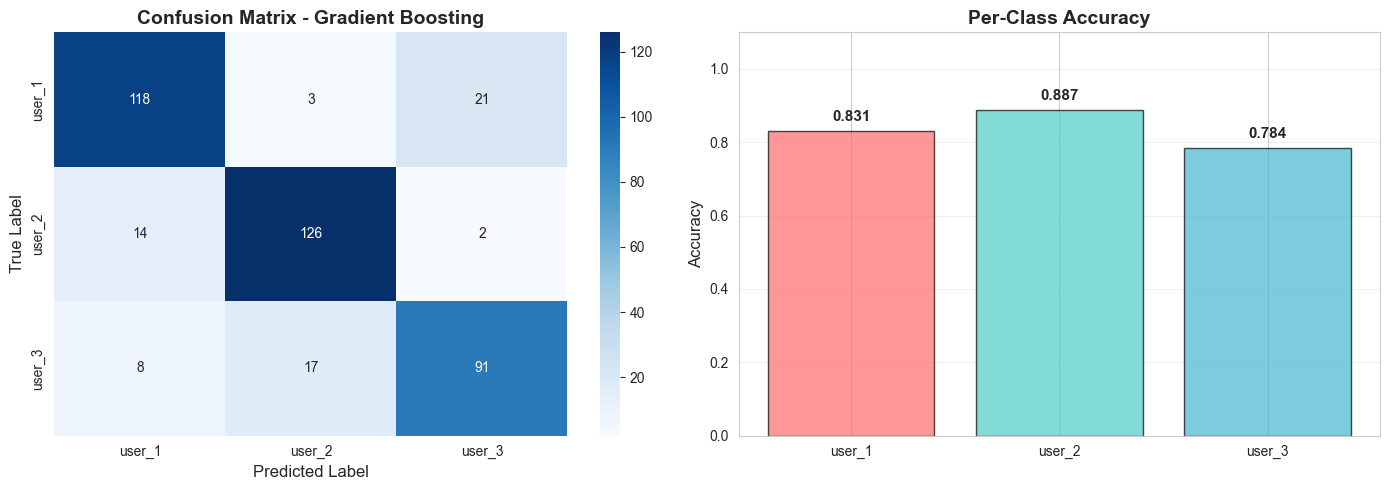

In [11]:
y_val_pred = best_clf.predict(X_val_split)

print("\nClassification Report:")
print(classification_report(y_val_split, y_val_pred, target_names=label_encoder.classes_))

# Confusion Matrix
cm_val = confusion_matrix(y_val_split, y_val_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot confusion matrix
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Per-class accuracy
class_accuracies = []
for i in range(len(label_encoder.classes_)):
    class_acc = cm_val[i, i] / cm_val[i, :].sum() if cm_val[i, :].sum() > 0 else 0
    class_accuracies.append(class_acc)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = axes[1].bar(label_encoder.classes_, class_accuracies, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1.1])
axes[1].grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, class_accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2, acc + 0.02, 
                f'{acc:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 12. Feature Importance

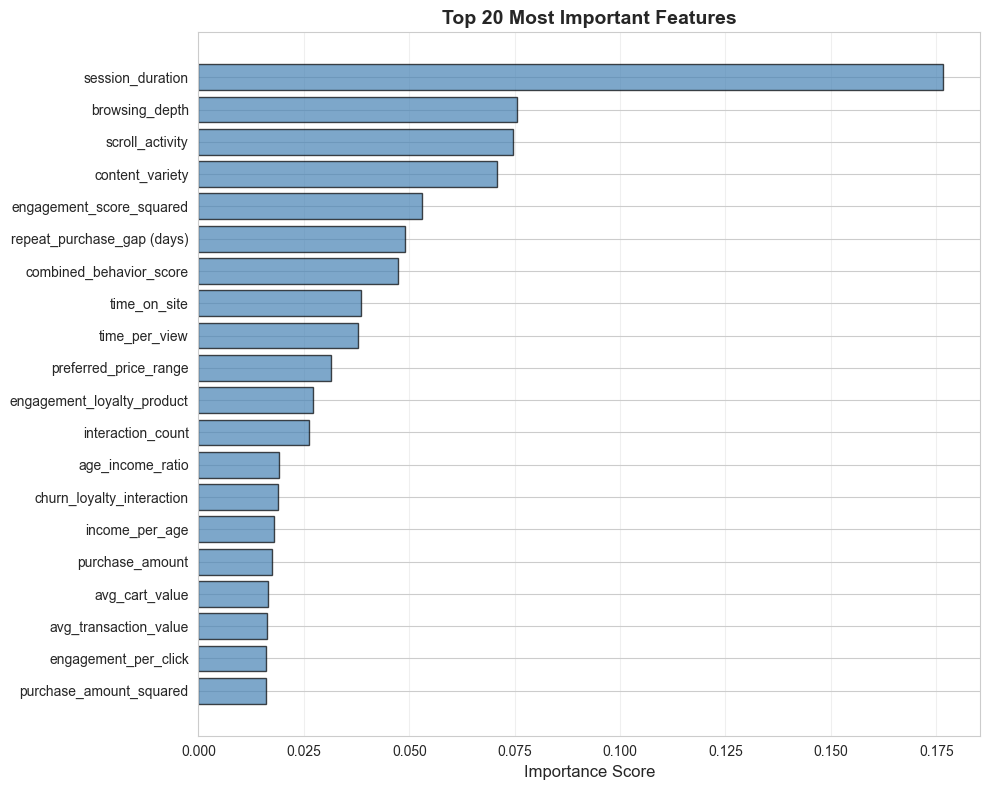


Top 10 Most Important Features:
  session_duration                         0.1765
  browsing_depth                           0.0755
  scroll_activity                          0.0747
  content_variety                          0.0707
  engagement_score_squared                 0.0529
  repeat_purchase_gap (days)               0.0491
  combined_behavior_score                  0.0472
  time_on_site                             0.0386
  time_per_view                            0.0378
  preferred_price_range                    0.0314


In [12]:
# Get feature importances
if hasattr(best_clf, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': selected_features,
        'importance': best_clf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Plot top 20 features
    plt.figure(figsize=(10, 8))
    top_n = min(20, len(feature_importance))
    top_features = feature_importance.head(top_n)
    
    plt.barh(range(top_n), top_features['importance'], color='steelblue', alpha=0.7, edgecolor='black')
    plt.yticks(range(top_n), top_features['feature'])
    plt.xlabel('Importance Score', fontsize=12)
    plt.title(f'Top {top_n} Most Important Features', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    for i, row in feature_importance.head(10).iterrows():
        print(f"  {row['feature']:40s} {row['importance']:.4f}")

## 13. Retrain on Full Training Data

In [13]:
print("\nRetraining on full training data...")
best_clf.fit(X_train_selected, y_train_full)

y_train_full_pred = best_clf.predict(X_train_selected)
train_full_acc = accuracy_score(y_train_full, y_train_full_pred)

print(f"✓ Full Training Set Accuracy: {train_full_acc:.4f} ({train_full_acc*100:.2f}%)")


Retraining on full training data...
✓ Full Training Set Accuracy: 1.0000 (100.00%)


## 14. Final Test Set Evaluation

In [14]:
print("="*70)
print("FINAL TEST SET EVALUATION")
print("="*70)

test_predictions = best_clf.predict(X_test_selected)

if y_test is not None:
    test_acc = accuracy_score(y_test, test_predictions)
    print(f"\n✓ TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)")
    
    if test_acc >= 0.90:
        print("\n🎯 TARGET ACHIEVED: 90%+ Accuracy!")
    elif test_acc >= 0.85:
        print("\n✓ Good accuracy - close to target")
    else:
        print("\n⚠ Below target - consider more feature engineering")
    
    print("\nTest Classification Report:")
    print(classification_report(y_test, test_predictions, target_names=label_encoder.classes_))
    
    print("\nPer-Class Test Accuracy:")
    cm_test = confusion_matrix(y_test, test_predictions)
    for i, user_type in enumerate(label_encoder.classes_):
        class_acc = cm_test[i, i] / cm_test[i, :].sum() if cm_test[i, :].sum() > 0 else 0
        print(f"  {user_type:10s}: {class_acc:.4f} ({class_acc*100:.2f}%)")
else:
    print("\nNo labels in test set")

print("\nPredicted Distribution:")
unique, counts = np.unique(test_predictions, return_counts=True)
for label_idx, count in zip(unique, counts):
    print(f"  {label_encoder.classes_[label_idx]:10s}: {count:4d} ({count/len(test_predictions)*100:5.1f}%)")

FINAL TEST SET EVALUATION

No labels in test set

Predicted Distribution:
  user_1    :  663 ( 33.1%)
  user_2    :  781 ( 39.1%)
  user_3    :  556 ( 27.8%)



Showing predictions for 10 random test examples:

Example 1 | User ID: U7386

PREDICTION: user_3 (Confidence: 48.8%)

Class Probabilities:
   user_1    :  30.8% 
   user_2    :  20.4% 
   user_3    :  48.8%  ← PREDICTED

Key Features:
   income                             : 26150
   clicks                             : 13
   purchase_amount                    : 976.64
   session_duration                   : 25.05
   content_variety                    : 0.65
   avg_monthly_spend                  : 392.15
   avg_cart_value                     : 100.90
   browsing_depth                     : 15

Example 2 | User ID: U5600

PREDICTION: user_1 (Confidence: 96.9%)

Class Probabilities:
   user_1    :  96.9%  ← PREDICTED
   user_2    :   1.8% 
   user_3    :   1.3% 

Key Features:
   income                             : 22251
   clicks                             : 10
   purchase_amount                    : 1064.17
   session_duration                   : 53.86
   content_variety             

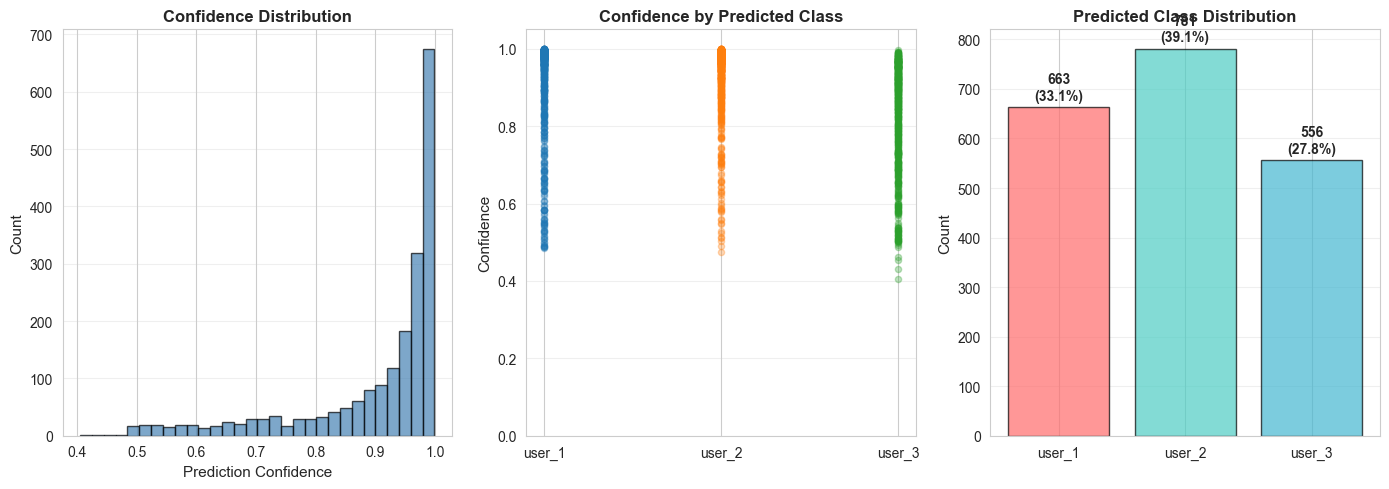

In [15]:

# Get prediction probabilities
test_proba = best_clf.predict_proba(X_test_selected)

# Show 10 random examples with detailed predictions
np.random.seed(42)
sample_indices = np.random.choice(len(test_users), size=min(10, len(test_users)), replace=False)

print(f"\nShowing predictions for {len(sample_indices)} random test examples:\n")

for i, idx in enumerate(sample_indices, 1):
    print(f"{'='*70}")
    print(f"Example {i} | User ID: {test_users.iloc[idx]['user_id']}")
    print('='*70)
    
    # Get prediction
    pred_label = label_encoder.classes_[test_predictions[idx]]
    confidence = test_proba[idx].max()
    
    print(f"\nPREDICTION: {pred_label} (Confidence: {confidence:.1%})")
    
    # Show actual if available
    if y_test is not None:
        actual_label = label_encoder.classes_[y_test[idx]]
        correct = pred_label == actual_label
        status = "CORRECT" if correct else "✗ INCORRECT"
        print(f"ACTUAL:     {actual_label} {status}")
    
    # Show probability breakdown
    print(f"\nClass Probabilities:")
    for j, cls in enumerate(label_encoder.classes_):
        prob = test_proba[idx][j]
        bar = "" * int(prob * 40)
        arrow = " ← PREDICTED" if cls == pred_label else ""
        print(f"   {cls:10s}: {prob:6.1%} {bar}{arrow}")
    
    # Show key feature values
    print(f"\nKey Features:")
    user_enhanced = test_users_enhanced.iloc[idx]
    
    # Show top 8 most important features for this user
    for feat in selected_features[:8]:
        if feat in user_enhanced.index:
            val = user_enhanced[feat]
            if pd.notna(val):
                if isinstance(val, (int, np.integer)):
                    print(f"   {feat:35s}: {val}")
                else:
                    print(f"   {feat:35s}: {val:.2f}")
    
    print()

# %%
# Summary statistics
print("="*70)
print("PREDICTION SUMMARY")
print("="*70)

print(f"\nConfidence Statistics:")
print(f"   Mean confidence: {test_proba.max(axis=1).mean():.1%}")
print(f"   Min confidence:  {test_proba.max(axis=1).min():.1%}")
print(f"   Max confidence:  {test_proba.max(axis=1).max():.1%}")

# Most confident predictions
print(f"\nTop 5 Most Confident Predictions:")
most_confident_idx = test_proba.max(axis=1).argsort()[-5:][::-1]
for idx in most_confident_idx:
    pred = label_encoder.classes_[test_predictions[idx]]
    conf = test_proba[idx].max()
    user_id = test_users.iloc[idx]['user_id']
    
    if y_test is not None:
        actual = label_encoder.classes_[y_test[idx]]
        status = "✓" if pred == actual else "✗"
        print(f"   User {user_id}: {pred} ({conf:.1%}) - Actual: {actual} {status}")
    else:
        print(f"   User {user_id}: {pred} ({conf:.1%})")

# Least confident predictions
print(f"\nTop 5 Least Confident Predictions:")
least_confident_idx = test_proba.max(axis=1).argsort()[:5]
for idx in least_confident_idx:
    pred = label_encoder.classes_[test_predictions[idx]]
    conf = test_proba[idx].max()
    user_id = test_users.iloc[idx]['user_id']
    
    if y_test is not None:
        actual = label_encoder.classes_[y_test[idx]]
        status = "✓" if pred == actual else "✗"
        print(f"   User {user_id}: {pred} ({conf:.1%}) - Actual: {actual} {status}")
    else:
        print(f"   User {user_id}: {pred} ({conf:.1%})")

# %%
# Visualize confidence distribution
plt.figure(figsize=(14, 5))

# Confidence histogram
plt.subplot(1, 3, 1)
plt.hist(test_proba.max(axis=1), bins=30, color='steelblue', alpha=0.7, edgecolor='black')
plt.xlabel('Prediction Confidence', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.title('Confidence Distribution', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Confidence by predicted class
plt.subplot(1, 3, 2)
for i, cls in enumerate(label_encoder.classes_):
    mask = test_predictions == i
    confidences = test_proba[mask].max(axis=1)
    plt.scatter([cls]*len(confidences), confidences, alpha=0.3, s=20)

plt.ylabel('Confidence', fontsize=11)
plt.title('Confidence by Predicted Class', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.ylim([0, 1.05])

# Prediction distribution
plt.subplot(1, 3, 3)
unique, counts = np.unique(test_predictions, return_counts=True)
class_names = [label_encoder.classes_[i] for i in unique]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
plt.bar(class_names, counts, color=colors[:len(class_names)], alpha=0.7, edgecolor='black')
plt.ylabel('Count', fontsize=11)
plt.title('Predicted Class Distribution', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for i, (cls, cnt) in enumerate(zip(class_names, counts)):
    plt.text(i, cnt + max(counts)*0.02, f'{cnt}\n({cnt/len(test_predictions)*100:.1f}%)', 
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()